In [1]:
import pandas as pd
import numpy as np
from tld import get_tld
import itertools
import joblib
import matplotlib.pyplot as plt
import pickle
import tldextract
from urllib.parse import urlparse
from http.client import HTTPConnection, HTTPSConnection
import requests
import os
from datetime import datetime, timedelta
import csv

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb


# **FEATURES EXTRACTION**

*PROTOCOL*

In [2]:
# Menggabungkan DataFrames
files = [
    ('merge_community.csv', ';', ['Website', 'Label']),
    ('urlcampus.csv', ';', ['Website', 'Label']),
    ('merge_global_bad_test2.csv', ',', ['_', 'Website', 'Label']),
    ('merge_indo_good.csv', ';', ['Website', 'Label'])
]
dfs = []
for file_name, sep, cols in files:
    path = f'Source\\{file_name}'
    if file_name.endswith('.csv'):
        dfs.append(pd.read_csv(path, sep=sep, names=cols))
    else:
        dfs.append(pd.read_excel(path))
df = pd.concat(dfs, ignore_index=True)

# Pembersihan URL
df['Website'] = df['Website'].str.replace(r'https?://|www\.|\s+', '', regex=True)

# Fungsi pemeriksaan protokol yang dioptimalkan
def protocol_check(url):
    for prefix in ['https://', 'http://']:
        try:
            response = requests.head(prefix + url, timeout=2)
            if response.status_code < 400:
                return 'HTTPS' if prefix == 'https://' else 'HTTP'
        except requests.RequestException:
            continue
    return 'malformed'

# Menyiapkan CSV dan logika pengecekan ulang
csv_path = 'checked_websites_test2.csv'
if not os.path.exists(csv_path):
    pd.DataFrame(columns=['Website', 'Label', 'LastChecked', 'protocol']).to_csv(csv_path, index=False)

checked_df = pd.read_csv(csv_path, on_bad_lines='warn')
checked_websites = dict(zip(checked_df['Website'], pd.to_datetime(checked_df['LastChecked'])))

# Pengecekan protokol dan penyimpanan ke CSV
today = datetime.now()
new_data = []

max_to_check = 20000
checked_count = 0

for i, row in df.iterrows():
    website = row['Website']
    label = row['Label']
    if website in checked_websites and today - checked_websites[website] <= timedelta(days=3):
        continue  # Data sudah ada dan masih relevan
    
    protocol = protocol_check(website)
    new_data.append({'Website': website, 'Label': label, 'LastChecked': today, 'protocol': protocol})
    checked_count += 1
    
    # Menyimpan setiap 1000 data
    if i % 1000 == 0 and i > 0:
        pd.DataFrame(new_data).to_csv(csv_path, mode='a', header=False, index=False)
        new_data.clear()
        print(f"Data saved up to index {i}")

    # Batasi jumlah total pengecekan
    if checked_count >= max_to_check:
        break

# Menyimpan sisa data yang belum disimpan
if new_data:
    pd.DataFrame(new_data).to_csv(csv_path, mode='a', header=False, index=False)

print("Data processing complete.")


Data saved up to index 1000
Data saved up to index 2000
Data saved up to index 3000
Data saved up to index 4000
Data saved up to index 5000
Data saved up to index 6000
Data saved up to index 7000
Data saved up to index 8000
Data saved up to index 9000
Data saved up to index 10000
Data saved up to index 11000
Data saved up to index 12000
Data saved up to index 13000
Data saved up to index 14000
Data saved up to index 15000
Data saved up to index 16000
Data saved up to index 17000
Data saved up to index 18000
Data saved up to index 19000
Data processing complete.


# IMPORT DATA

In [3]:
df = pd.read_csv(r'checked_websites_test2.csv')
df.loc[(df['protocol'] == 'HTTP'), 'Website'] = 'http://'+df['Website']
df.loc[(df['protocol'] == 'HTTPS'), 'Website'] = 'https://'+df['Website']

*TLD*

In [4]:
tld = []
for i in range (len(df)):
 # if
  tld.append(get_tld((df['Website'])[i], fail_silently=True, fix_protocol=True))
  #print(tld)
df['tld'] = tld

In [5]:
df.drop(df[df['protocol']=="malformed"].index, inplace = True)
df.drop(df.loc[df['tld'].isna()].index, inplace = True)
df.reset_index(drop=True, inplace = True)

*OTHER FEATURES*

In [6]:
subdomain = []
domain = []
path = []

for i in range(len(df)):
    subdomain.append(tldextract.extract(df['Website'][i]).subdomain)
    domain.append(tldextract.extract(df['Website'][i]).domain)
    path.append(urlparse(df['Website'][i]).path)
    i=i+1
    
df['subdomain'] = subdomain
df['domain'] = domain
df['path'] = path

df['Website'] = df['Website'].replace(r'http://', '', regex=True).replace(r'https://', '', regex=True).replace(r'www.', '', regex=True).replace(r'www\S+', '', regex=True).replace(' ', '')

In [7]:
def fitur(df): 
    sy = ['@','.','-','_','/','?','=','&',',','%','#',';']
    sl = ['','A-Za-z','0-9','@.-_/?=&,%#;'] #(:/,#%\=@.)?
    nm = ['At','Dot','Dash','UnderScore', 'Slash', 'Question', 'Equal', 'Ampersand', 'Comma', 'Percent', 'Hastag', 'Semicolon']
    ln = ['URL', 'Alphabet', 'Non-alphabet', 'Spec-character']
    en = ['Website','domain','subdomain']
    for j in range(len(en)):
        for k in range(len(sl)): 
            if k==0:
                df['Len_'+ln[k]+'_'+en[j]] = df[en[j]].str.len()
            else:
                df['Len_'+ln[k]+'_'+en[j]] = df[en[j]].str.count('['+sl[k]+']')
            k=k+1
        for i in range(len(sy)):
            df['Count_'+nm[i]+'_'+en[j]] = df[en[j]].str.count('['+sy[i]+']')
            i=i+1
        j=j+1
    return df

In [8]:
df = fitur(df)
df.replace('',np.nan,inplace=True)
df['ratio_url_path'] = df['Website'].str.len() / df['path'].str.len()
df['ratio_digit_url'] = df['Website'].str.count('[0-9]') / df['Website'].str.len()
df

,Website,Label,LastChecked,protocol,tld,subdomain,domain,path,Len_URL_Website,Len_Alphabet_Website,...,Count_Slash_subdomain,Count_Question_subdomain,Count_Equal_subdomain,Count_Ampersand_subdomain,Count_Comma_subdomain,Count_Percent_subdomain,Count_Hastag_subdomain,Count_Semicolon_subdomain,ratio_url_path,ratio_digit_url
0,123dok.com,good,2026-01-15 09:03:50.676270,HTTP,com,NaN,123dok,NaN,10,6,...,0,0,0,0,0,0,0,0,NaN,0.3
1,kuyhaa-me.com,good,2026-01-15 09:03:50.676270,HTTP,com,NaN,kuyhaa-me,NaN,13,11,...,0,0,0,0,0,0,0,0,NaN,0.0
2,screenmirrorapp.com,good,2026-01-15 09:03:50.676270,HTTP,com,NaN,screenmirrorapp,NaN,19,18,...,0,0,0,0,0,0,0,0,NaN,0.0
3,carisinyal.com,good,2026-01-15 09:03:50.676270,HTTPS,com,NaN,carisinyal,NaN,14,13,...,0,0,0,0,0,0,0,0,NaN,0.0
4,bit.ly/rfubima,good,2026-01-15 09:03:50.676270,HTTPS,ly,NaN,bit,/rfubima,14,12,...,0,0,0,0,0,0,0,0,1.75,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4731,rkb.pekalongankota.go.id,good,2026-01-15 09:03:50.676270,HTTPS,go.id,rkb,pekalongankota,NaN,24,21,...,0,0,0,0,0,0,0,0,NaN,0.0
4732,tpad.pekalongankota.go.id,good,2026-01-15 09:03:50.676270,HTTPS,go.id,tpad,pekalongankota,NaN,25,22,...,0,0,0,0,0,0,0,0,NaN,0.0
4733,ppid.pekalongankota.go.id,good,2026-01-15 09:03:50.676270,HTTPS,go.id,ppid,pekalongankota,NaN,25,22,...,0,0,0,0,0,0,0,0,NaN,0.0
4734,gafe.pekalongankota.go.id,good,2026-01-15 09:03:50.676270,HTTPS,go.id,gafe,pekalongankota,NaN,25,22,...,0,0,0,0,0,0,0,0,NaN,0.0


# **PREPROCESSING**

In [9]:
# move the 'label' column to last column
pop = df.pop('Label')
df = pd.concat([df, pop], axis=1)

# delete malformed data
df.drop(df[df['protocol']=="malformed"].index, inplace = True)
df.reset_index(drop=True, inplace = True)

# drop features that aren't trained 
del df['subdomain'], df['domain'], df['path']

df

,Website,LastChecked,protocol,tld,Len_URL_Website,Len_Alphabet_Website,Len_Non-alphabet_Website,Len_Spec-character_Website,Count_At_Website,Count_Dot_Website,...,Count_Question_subdomain,Count_Equal_subdomain,Count_Ampersand_subdomain,Count_Comma_subdomain,Count_Percent_subdomain,Count_Hastag_subdomain,Count_Semicolon_subdomain,ratio_url_path,ratio_digit_url,Label
0,123dok.com,2026-01-15 09:03:50.676270,HTTP,com,10,6,3,4,0,1,...,0,0,0,0,0,0,0,NaN,0.3,good
1,kuyhaa-me.com,2026-01-15 09:03:50.676270,HTTP,com,13,11,0,1,0,1,...,0,0,0,0,0,0,0,NaN,0.0,good
2,screenmirrorapp.com,2026-01-15 09:03:50.676270,HTTP,com,19,18,0,1,0,1,...,0,0,0,0,0,0,0,NaN,0.0,good
3,carisinyal.com,2026-01-15 09:03:50.676270,HTTPS,com,14,13,0,1,0,1,...,0,0,0,0,0,0,0,NaN,0.0,good
4,bit.ly/rfubima,2026-01-15 09:03:50.676270,HTTPS,ly,14,12,0,2,0,1,...,0,0,0,0,0,0,0,1.75,0.0,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4731,rkb.pekalongankota.go.id,2026-01-15 09:03:50.676270,HTTPS,go.id,24,21,0,3,0,3,...,0,0,0,0,0,0,0,NaN,0.0,good
4732,tpad.pekalongankota.go.id,2026-01-15 09:03:50.676270,HTTPS,go.id,25,22,0,3,0,3,...,0,0,0,0,0,0,0,NaN,0.0,good
4733,ppid.pekalongankota.go.id,2026-01-15 09:03:50.676270,HTTPS,go.id,25,22,0,3,0,3,...,0,0,0,0,0,0,0,NaN,0.0,good
4734,gafe.pekalongankota.go.id,2026-01-15 09:03:50.676270,HTTPS,go.id,25,22,0,3,0,3,...,0,0,0,0,0,0,0,NaN,0.0,good


In [10]:
# convert word to numberic
df.loc[(df['protocol'] == 'HTTP'), 'protocol'] = 1
df.loc[(df['protocol'] == 'HTTPS'), 'protocol'] = 2

tld = pd.unique(df['tld'])
labelen = LabelEncoder()
labelen.fit(tld)
df['tld'] = labelen.transform(df['tld'])

df.fillna(0,inplace=True)

df.loc[(df['Label'] == 'bad'), 'Label'] = 0
df.loc[(df['Label'] == 'good'), 'Label'] = 1
df


,Website,LastChecked,protocol,tld,Len_URL_Website,Len_Alphabet_Website,Len_Non-alphabet_Website,Len_Spec-character_Website,Count_At_Website,Count_Dot_Website,...,Count_Question_subdomain,Count_Equal_subdomain,Count_Ampersand_subdomain,Count_Comma_subdomain,Count_Percent_subdomain,Count_Hastag_subdomain,Count_Semicolon_subdomain,ratio_url_path,ratio_digit_url,Label
0,123dok.com,2026-01-15 09:03:50.676270,1,25,10,6,3,4,0,1,...,0,0,0,0,0,0,0,0.00,0.3,1
1,kuyhaa-me.com,2026-01-15 09:03:50.676270,1,25,13,11,0,1,0,1,...,0,0,0,0,0,0,0,0.00,0.0,1
2,screenmirrorapp.com,2026-01-15 09:03:50.676270,1,25,19,18,0,1,0,1,...,0,0,0,0,0,0,0,0.00,0.0,1
3,carisinyal.com,2026-01-15 09:03:50.676270,2,25,14,13,0,1,0,1,...,0,0,0,0,0,0,0,0.00,0.0,1
4,bit.ly/rfubima,2026-01-15 09:03:50.676270,2,76,14,12,0,2,0,1,...,0,0,0,0,0,0,0,1.75,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4731,rkb.pekalongankota.go.id,2026-01-15 09:03:50.676270,2,58,24,21,0,3,0,3,...,0,0,0,0,0,0,0,0.00,0.0,1
4732,tpad.pekalongankota.go.id,2026-01-15 09:03:50.676270,2,58,25,22,0,3,0,3,...,0,0,0,0,0,0,0,0.00,0.0,1
4733,ppid.pekalongankota.go.id,2026-01-15 09:03:50.676270,2,58,25,22,0,3,0,3,...,0,0,0,0,0,0,0,0.00,0.0,1
4734,gafe.pekalongankota.go.id,2026-01-15 09:03:50.676270,2,58,25,22,0,3,0,3,...,0,0,0,0,0,0,0,0.00,0.0,1


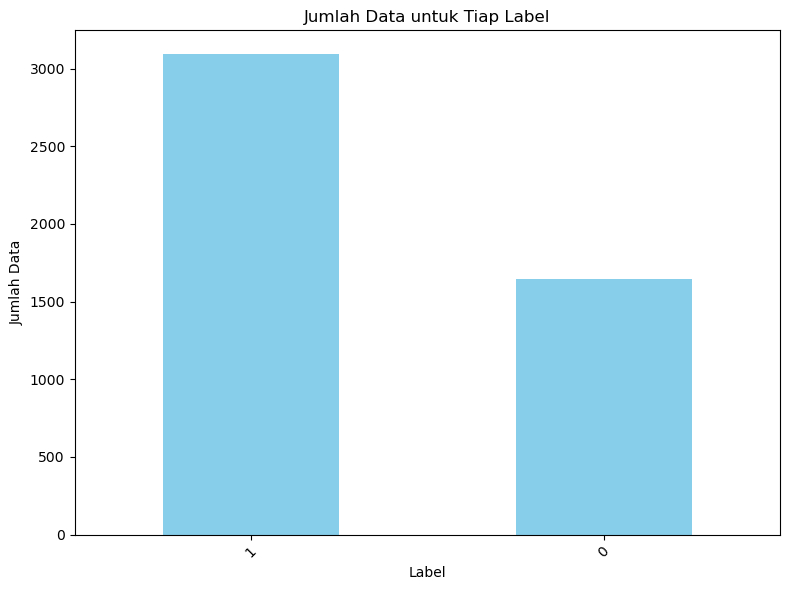

In [11]:
# Misalkan df adalah DataFrame Anda dengan kolom label yang ingin divisualisasikan

# Hitung jumlah masing-masing label
label_counts = df['Label'].value_counts()

# Plot diagram batang
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Jumlah Data untuk Tiap Label')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **MODEL**

In [12]:
def plot_confusion_matrix(cm, classes,
   normalize=False,
   title='Confusion matrix',
   cmap=plt.cm.Blues):
 
#Add Normalization Option
   if normalize:
     cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
     print('Normalized confusion matrix')
   else:
     print('Confusion matrix, without normalization')
 
# print(cm)
 
   plt.imshow(cm, interpolation='nearest', cmap=cmap)
   plt.title(title)
   plt.colorbar()
   tick_marks = np.arange(len(classes))
   plt.xticks(tick_marks, classes, rotation=45)
   plt.yticks(tick_marks, classes)
 
   fmt = '.2f' if normalize else 'd'
   thresh = cm.max() / 2.
   for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt), horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
 
   plt.tight_layout()
   plt.ylabel('True label')
   plt.xlabel('Predicted label')

In [13]:
diag_text = ['bad', 'good']

# Drop kolom LastChecked
df.drop('LastChecked', axis=1, inplace=True)  # axis=1 untuk menghapus kolom, inplace=True untuk mengubah DataFrame asli

X = df.iloc[:,1:-1].values
Y = df.iloc[:,[-1]].astype('int')
#Y = df.iloc[:,[-1]].values

scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

In [14]:
m = scaler.mean_
s = np.sqrt(scaler.var_)
m,s

(array([1.56566723e+00, 4.51809544e+01, 3.43114443e+01, 2.77122044e+01,
        2.19151182e+00, 6.36317568e+00, 1.68918919e-03, 2.34184966e+00,
        2.99831081e-01, 1.05574324e-01, 1.10071791e+00, 7.49577703e-02,
        1.96790541e-01, 1.14864865e-01, 1.68918919e-03, 8.69932432e-02,
        1.90033784e-03, 6.29222973e-02, 8.87816723e+00, 8.78758446e+00,
        5.51097973e-02, 5.53209459e-02, 0.00000000e+00, 0.00000000e+00,
        3.54729730e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 4.78969595e+00, 4.46600507e+00,
        1.71452703e-01, 2.47466216e-01, 0.00000000e+00, 7.30574324e-02,
        7.91807432e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.50312033e+00, 3.42978774e-02]),
 array([ 0.49566906, 24.25764334, 33.29199244, 24.71943382,  7

In [15]:
df['protocol'] = df['protocol'].replace({'HTTP': 1, 'HTTPS': 2, 'malformed': 0})
df['protocol'] = df['protocol'].astype(int)  # pastikan bukan object

feature_names =  df.select_dtypes(include=[np.number])

print("Fitur yang digunakan untuk pelatihan model:")
for i, f in enumerate(feature_names):
    print(f"{i+1}. {f}")

Fitur yang digunakan untuk pelatihan model:
1. protocol
2. tld
3. Len_URL_Website
4. Len_Alphabet_Website
5. Len_Non-alphabet_Website
6. Len_Spec-character_Website
7. Count_At_Website
8. Count_Dot_Website
9. Count_Dash_Website
10. Count_UnderScore_Website
11. Count_Slash_Website
12. Count_Question_Website
13. Count_Equal_Website
14. Count_Ampersand_Website
15. Count_Comma_Website
16. Count_Percent_Website
17. Count_Hastag_Website
18. Count_Semicolon_Website
19. Len_URL_domain
20. Len_Alphabet_domain
21. Len_Non-alphabet_domain
22. Len_Spec-character_domain
23. Count_At_domain
24. Count_Dot_domain
25. Count_Dash_domain
26. Count_UnderScore_domain
27. Count_Slash_domain
28. Count_Question_domain
29. Count_Equal_domain
30. Count_Ampersand_domain
31. Count_Comma_domain
32. Count_Percent_domain
33. Count_Hastag_domain
34. Count_Semicolon_domain
35. Len_URL_subdomain
36. Len_Alphabet_subdomain
37. Len_Non-alphabet_subdomain
38. Len_Spec-character_subdomain
39. Count_At_subdomain
40. Count_Do

D:\Users\bsi90971\AppData\Local\Temp\ipykernel_80136\3968952173.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['protocol'] = df['protocol'].replace({'HTTP': 1, 'HTTPS': 2, 'malformed': 0})


In [16]:
X = feature_names
y = df['Label']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size = 0.20, 
    random_state= 7,
    stratify = Y
)

In [17]:
def confusion(kla, train_x, train_y, test_x, testlabel):
    best_accuracy = 0
    best_model = None
    best_filename = ''

    if kla == 'RF':
        param_range = range(50, 501, 50)
        param_name = 'n_estimators'
        model_prefix = 'RF'

    elif kla == 'KNN':
        param_range = range(1, 11)
        param_name = 'n_neighbors'
        model_prefix = 'KNN'

    elif kla == 'XG':
        param_range = [round(0.1 * i + 0.1, 1) for i in range(10)]
        param_name = 'learning_rate'
        model_prefix = 'XG'
    
    elif kla == 'LGBM':
        param_range = range(10, 101, 10)
        param_name = 'num_leaves'
        model_prefix = 'LGBM'

    for param in param_range:
        if kla == 'RF':
            classifier = RandomForestClassifier(n_estimators=param, criterion='entropy', random_state=0)
        elif kla == 'KNN':
            classifier = KNeighborsClassifier(n_neighbors=param, metric='minkowski', p=2)
        elif kla == 'XG':
            classifier = xgb.XGBClassifier(random_state=0, learning_rate=param)
        elif kla == 'LGBM':
            classifier = lgb.LGBMClassifier(num_leaves=param, random_state=0)

        classifier.fit(train_x, train_y)
        predictlabel = classifier.predict(test_x)
        accuracy = accuracy_score(testlabel, predictlabel)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = classifier
            print(f'\n\nChanging the {param_name} to {param}')
            print(f'Accuracy: {accuracy * 100:.2f}')
            print('Classification Report:')
            print(classification_report(testlabel, predictlabel, digits=4))
            print('Confusion Matrix:')
            print(confusion_matrix(testlabel, predictlabel))
            best_filename = f'{model_prefix}_{param}_armd.sav'

    if best_model is not None:
        joblib.dump(best_model, best_filename)


In [18]:
print(y_train.value_counts())

Label
1        2473
0        1315
Name: count, dtype: int64


Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Absolute Error: 0.035864978902953586
Accuracy: 96.41
Classification Report:
              precision    recall  f1-score   support

         bad     0.9178    0.9848    0.9501       329
        good     0.9916    0.9532    0.9720       619

    accuracy                         0.9641       948
   macro avg     0.9547    0.9690    0.9611       948
weighted avg     0.9660    0.9641    0.9644       948

Confusion matrix, without normalization


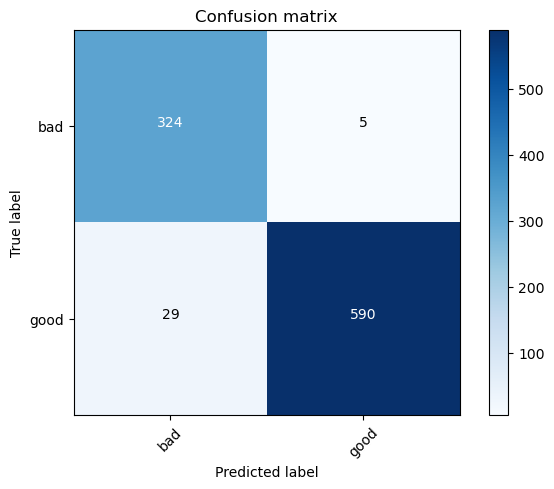

In [19]:
from sklearn.model_selection import GridSearchCV

# Definisikan parameter yang ingin diuji
parameters = {
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto'],  # Atur gamma sesuai kebutuhan Anda
    'C': [0.1, 1, 10],  # Atur nilai C sesuai kebutuhan Anda
    'probability': [True]
}

# Inisialisasi model SVC
svm_model = SVC(random_state=0)

# Buat objek GridSearchCV
grid_search = GridSearchCV(svm_model, parameters, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Lakukan pencarian parameter terbaik menggunakan data pelatihan (x_train dan y_train)
grid_search.fit(x_train, y_train)

# Ambil model terbaik setelah proses pencarian
best_svm_model = grid_search.best_estimator_

# Gunakan model terbaik untuk melakukan prediksi
y_pred = best_svm_model.predict(x_test)

# Tampilkan metrik evaluasi
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Accuracy: {0:.2f}'.format(accuracy_score(y_test, y_pred) * 100))
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=diag_text, digits=4))
conf_mtx = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mtx, diag_text, normalize=False)

# **Analisis Feature Importance**

In [20]:
def plot_feature_importance_final(model, feature_names=None):
    """
    Plot feature importance dari model XGBoost tanpa pipeline
    """
    importance_scores = model.feature_importances_

    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(len(importance_scores))]

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(12, 8))

    bars = plt.barh(np.arange(len(importance_df)), 
                    importance_df['Importance'],
                    color='#2563eb',
                    height=0.6)

    plt.yticks(np.arange(len(importance_df)), importance_df['Feature'], fontsize=10)

    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2,
                 f'{width:.4f}', 
                 ha='left', va='center', 
                 fontsize=9)

    plt.grid(True, axis='x', linestyle='--', alpha=0.3)
    plt.grid(False, axis='y')

    plt.title('Feature Importance Scores', 
              pad=20, fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)

    plt.tight_layout()
    plt.show()

    return importance_df


# **Random Forest**

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 100}
Mean Absolute Error: 0.028481012658227847
Accuracy: 97.15
Classification Report:
              precision    recall  f1-score   support

         bad     0.9548    0.9635    0.9592       329
        good     0.9805    0.9758    0.9781       619

    accuracy                         0.9715       948
   macro avg     0.9677    0.9696    0.9686       948
weighted avg     0.9716    0.9715    0.9715       948

Confusion Matrix:
Confusion matrix, without normalization


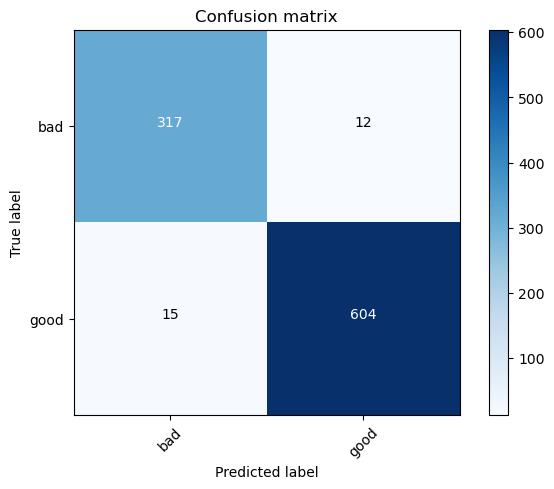

In [21]:
# Definisikan parameter grid yang ingin diuji
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30]
}

# Inisialisasi model RandomForest
rf_model = RandomForestClassifier(random_state=0)

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)

# Pastikan y_train berbentuk 1D array
y_train = np.ravel(y_train)

# Latih model menggunakan GridSearch
grid_search.fit(x_train, y_train)

# Dapatkan model terbaik dari grid search
best_classifierRF = grid_search.best_estimator_

# Prediksi dengan data uji
y_pred = best_classifierRF.predict(x_test)

# Evaluasi hasil
print("\nBest Parameters:", grid_search.best_params_)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Accuracy: {0:.2f}".format(accuracy_score(y_test, y_pred) * 100))
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=diag_text, digits=4))
print("Confusion Matrix:")
conf_mtx = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mtx, diag_text, normalize=False)


              Feature Importance Analysis - Final Model               


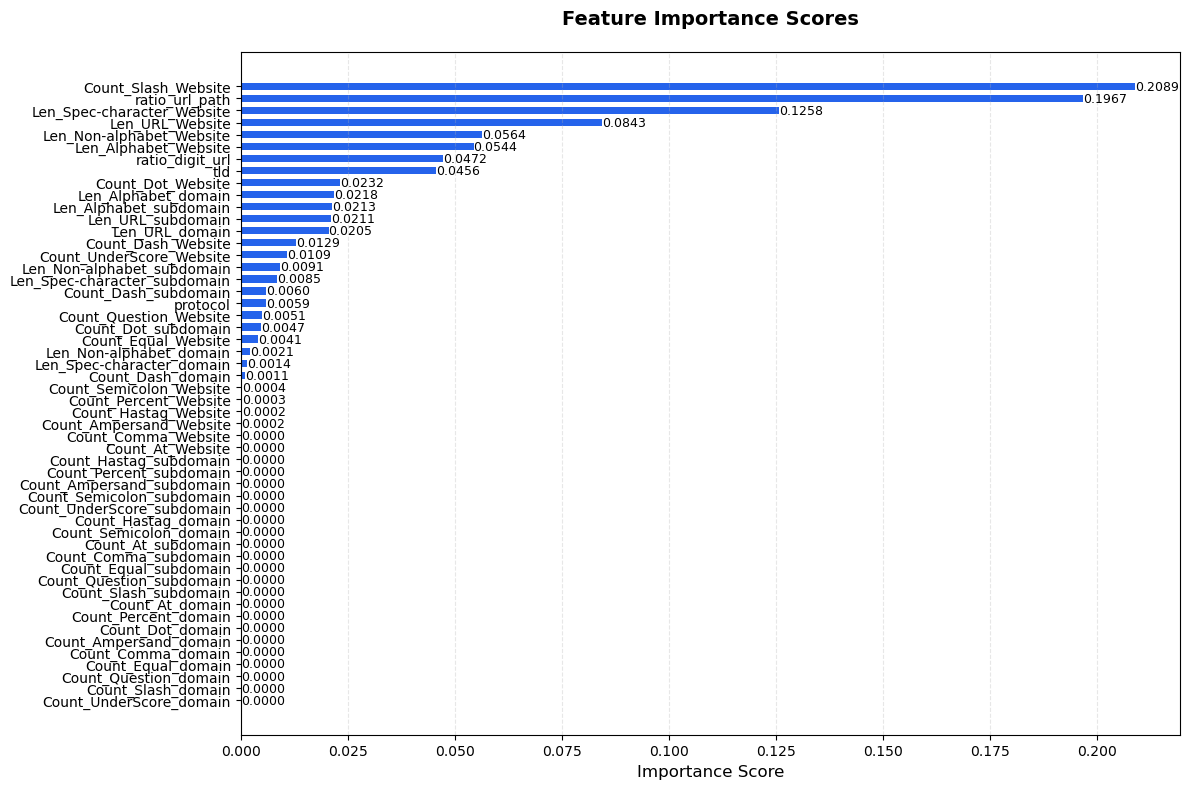

In [22]:
print("\n" + "="*70)
print("Feature Importance Analysis - Final Model".center(70))
print("="*70)

importance_df = plot_feature_importance_final(best_classifierRF, X.columns.tolist())

# **K-Nearest Neighbors**

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Mean Absolute Error: 0.028481012658227847
Accuracy: 97.15
Classification Report:
              precision    recall  f1-score   support

         bad     0.9467    0.9726    0.9595       329
        good     0.9852    0.9709    0.9780       619

    accuracy                         0.9715       948
   macro avg     0.9660    0.9718    0.9688       948
weighted avg     0.9719    0.9715    0.9716       948

Confusion Matrix:
Confusion matrix, without normalization


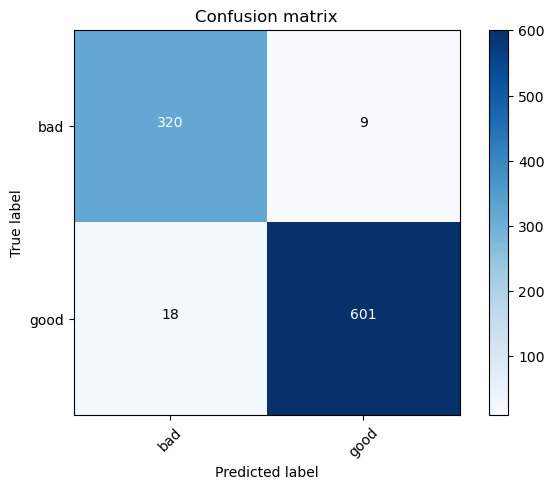

In [23]:
# Definisikan parameter grid yang ingin diuji
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

# Inisialisasi model KNN
knn_model = KNeighborsClassifier()

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=knn_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)

# Latih model menggunakan GridSearch
grid_search.fit(x_train, y_train)

# Dapatkan model terbaik dari grid search
best_classifierKNN = grid_search.best_estimator_

# Prediksi dengan data uji
y_pred = best_classifierKNN.predict(x_test)

# Evaluasi hasil
print("\nBest Parameters:", grid_search.best_params_)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Accuracy: {0:.2f}".format(accuracy_score(y_test, y_pred) * 100))
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=diag_text, digits=4))
print("Confusion Matrix:")
conf_mtx = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mtx, diag_text, normalize=False)

# Optional: Jika kamu masih ingin pakai fungsi confusion() untuk perbandingan
# confusion(kla='KNN', train_x=x_train, train_y=y_train, test_x=x_test, testlabel=y_test)

# **XGBoost**

D:\Users\bsi90971\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [17:34:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
D:\Users\bsi90971\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [17:34:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
D:\Users\bsi90971\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [17:34:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
D:\Users\bsi90971\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [17:34:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\

Best Parameters: {'learning_rate': 0.8, 'n_estimators': 250}
Mean Absolute Error: 0.023206751054852322
Accuracy: 97.68
Classification Report:
              precision    recall  f1-score   support

         bad     0.9666    0.9666    0.9666       329
        good     0.9822    0.9822    0.9822       619

    accuracy                         0.9768       948
   macro avg     0.9744    0.9744    0.9744       948
weighted avg     0.9768    0.9768    0.9768       948

Confusion Matrix:
Confusion matrix, without normalization


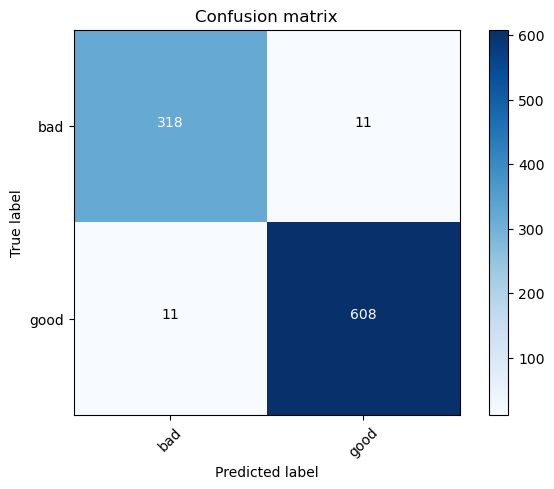

In [24]:
# Inisialisasi model XGBoost
classifierXG = xgb.XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')

# Tentukan grid parameter yang ingin dijelajahi
param_grid = {
    'n_estimators': range(50, 501, 50),
    'learning_rate': [round(0.1 * i + 0.1, 1) for i in range(10)]
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=classifierXG, param_grid=param_grid, cv=5, scoring='accuracy')

# Ubah bentuk y_train menjadi array 1D
y_train = np.ravel(y_train)

# Latih model menggunakan data training
grid_search.fit(x_train, y_train)

# Dapatkan model terbaik setelah pelatihan
best_classifierXG = grid_search.best_estimator_

# Prediksi menggunakan model terbaik
y_pred = best_classifierXG.predict(x_test)

# Tampilkan hasil evaluasi
print('Best Parameters:', grid_search.best_params_)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Accuracy: {0:.2f}'.format(accuracy_score(y_test, y_pred) * 100))
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=diag_text, digits=4))
print('Confusion Matrix:')
conf_mtx = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mtx, diag_text, normalize=False)


              Feature Importance Analysis - Final Model               


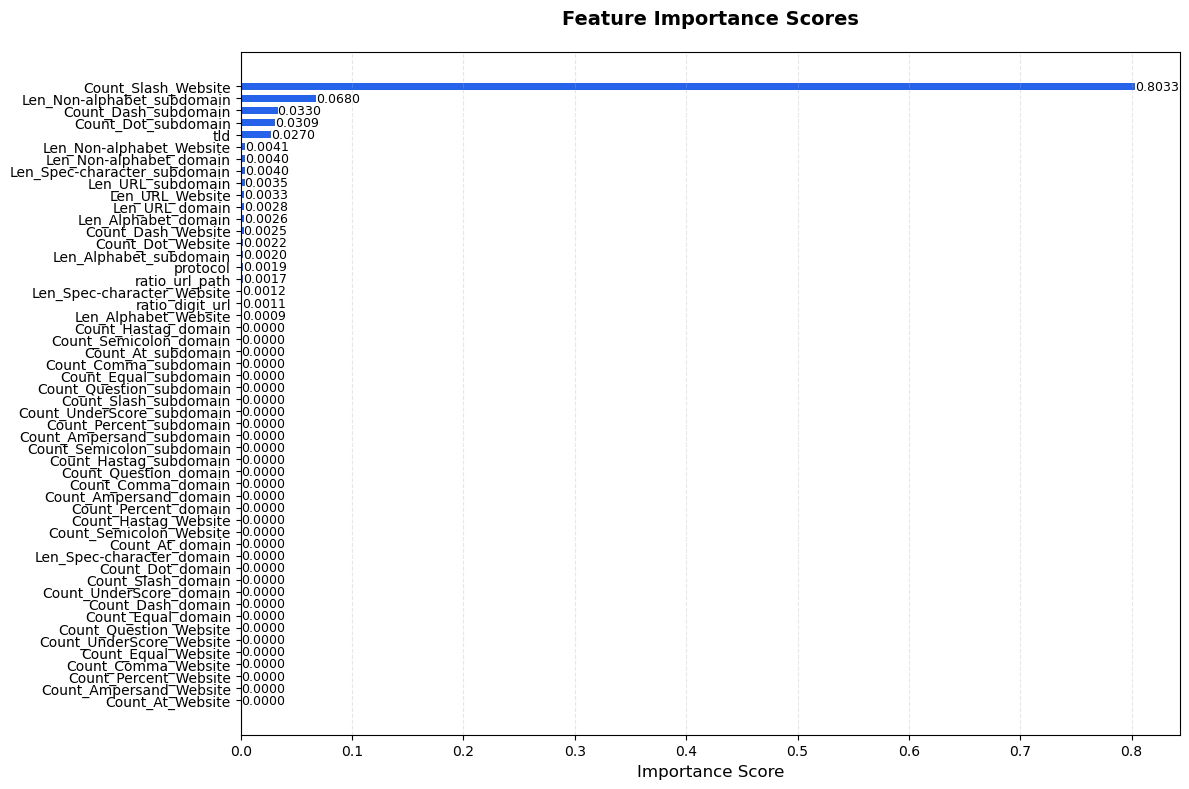

In [25]:
print("\n" + "="*70)
print("Feature Importance Analysis - Final Model".center(70))
print("="*70)

importance_df = plot_feature_importance_final(best_classifierXG, X.columns.tolist())

# **LightGBM**

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Info] Number of positive: 2473, number of negative: 1315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1156
[LightGBM] [Info] Number of data points in the train set: 3788, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.652851 -> initscore=0.631595
[LightGBM] [Info] Start training from score 0.631595
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

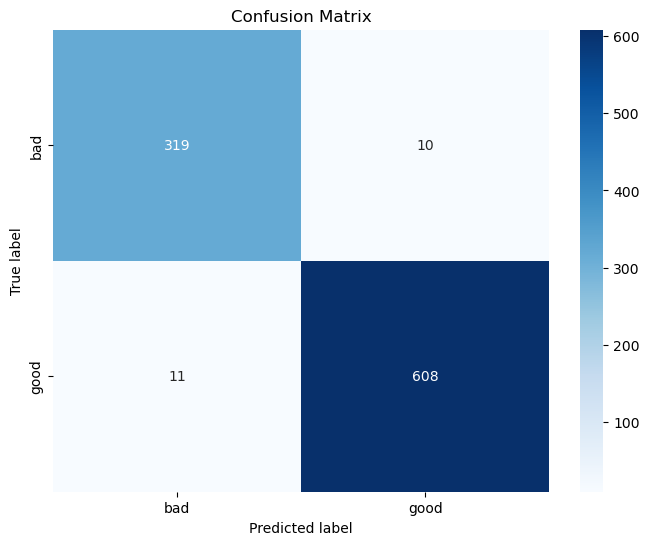

In [26]:
# Inisialisasi model LightGBM
classifierLGB = lgb.LGBMClassifier(random_state=0)

# Jika ingin tuning hyperparameter (GridSearchCV), kamu bisa pakai ini:
param_grid = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300]
}

grid_search = GridSearchCV(estimator=classifierLGB, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Ubah y_train jadi 1 dimensi jika perlu
y_train_flat = np.ravel(y_train)

# Latih model dengan pencarian parameter terbaik
grid_search.fit(x_train, y_train_flat)

# Ambil model terbaik
best_classifierLGB = grid_search.best_estimator_

# Prediksi dengan model terbaik
y_pred = best_classifierLGB.predict(x_test)

# Tampilkan hasil evaluasi
print('Best Parameters:', grid_search.best_params_)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, y_pred) * 100))
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=diag_text, digits=4))
conf_mtx = confusion_matrix(y_test, y_pred)

# Fungsi untuk plot confusion matrix (kalau belum ada, definisikan)
def plot_confusion_matrix(cm, class_names, normalize=False):
    import seaborn as sns

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

# Plot confusion matrix
plot_confusion_matrix(conf_mtx, diag_text, normalize=False)



              Feature Importance Analysis - Final Model               


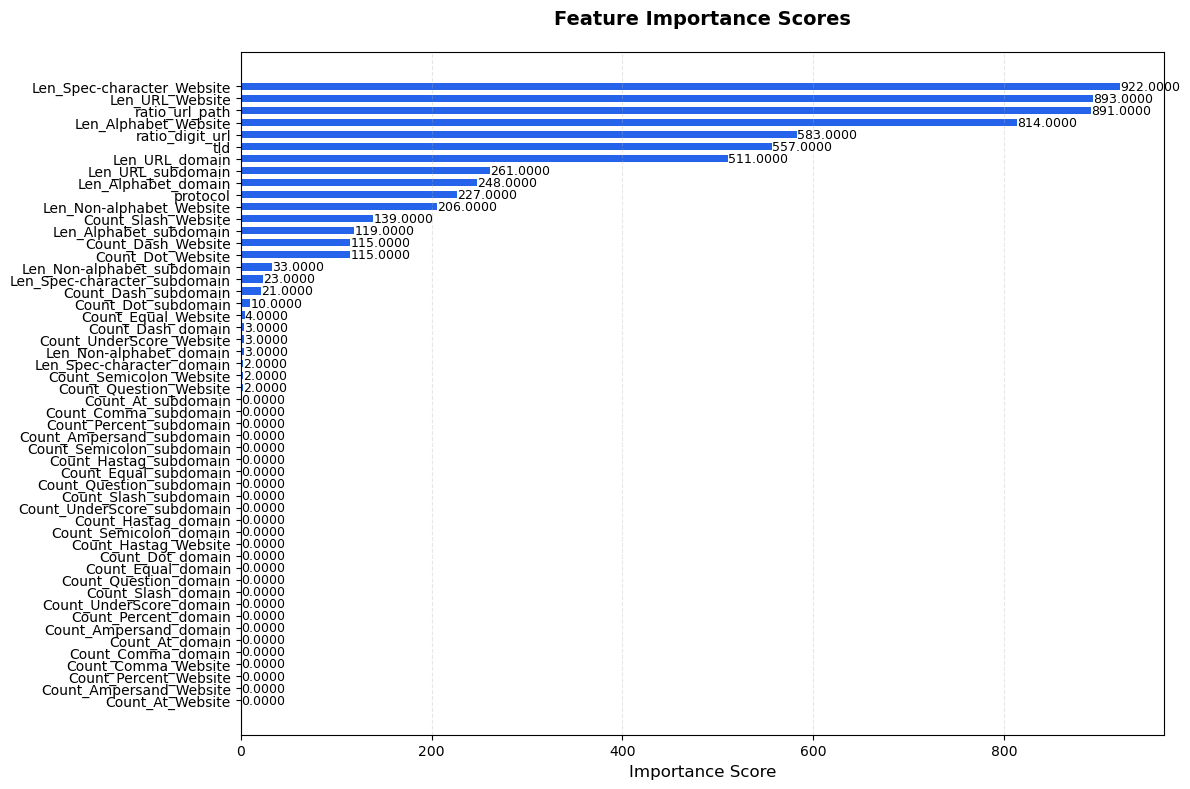

In [27]:
print("\n" + "="*70)
print("Feature Importance Analysis - Final Model".center(70))
print("="*70)

importance_df = plot_feature_importance_final(best_classifierLGB, X.columns.tolist())

# **THE BEST MODEL**

D:\Users\bsi90971\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [17:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "probability" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE: 0.02215190
Accuracy: 97.78
Classification Report:
              precision    recall  f1-score   support

         bad     0.9695    0.9666    0.9680       329
        good     0.9823    0.9838    0.9831       619

    accuracy                         0.9778       948
   macro avg     0.9759    0.9752    0.9755       948
weighted avg     0.9778    0.9778    0.9778       948



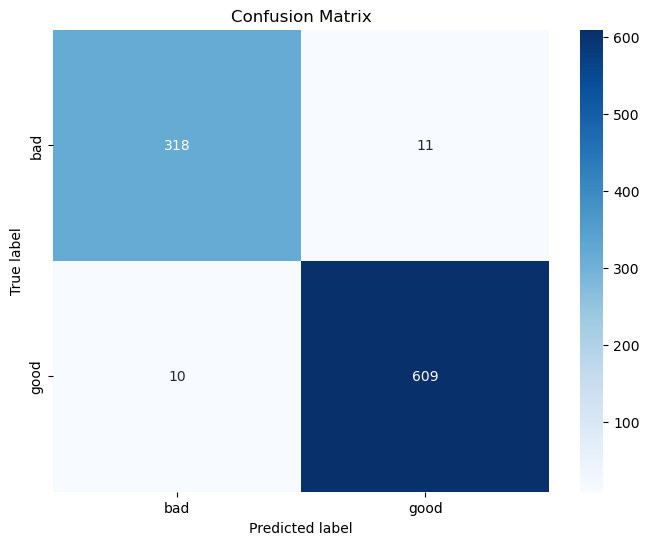

In [28]:
modelXGB=xgb.XGBClassifier(random_state=0, learning_rate=0.3, probability = True)
modelXGB.fit(x_train,y_train)

def XGB(X_Test, Ytest):
    Y_PredSVM = modelXGB.predict(X_Test)
    print('MAE: {0:.8f}'.format(mean_absolute_error(Ytest, Y_PredSVM)))
    #print()
    accuracy = accuracy_score(Ytest, Y_PredSVM)
    print('Accuracy: {0:.2f}'.format(accuracy * 100.0))
    print('Classification Report:')
    print(classification_report(Ytest, Y_PredSVM, target_names = diag_text, digits=4))
    confusion_mtx = confusion_matrix(Ytest, Y_PredSVM)
    plot_confusion_matrix(confusion_mtx,diag_text,normalize=False)

    return Y_PredSVM

final_model = XGB(x_test, y_test)

# **SHAP**

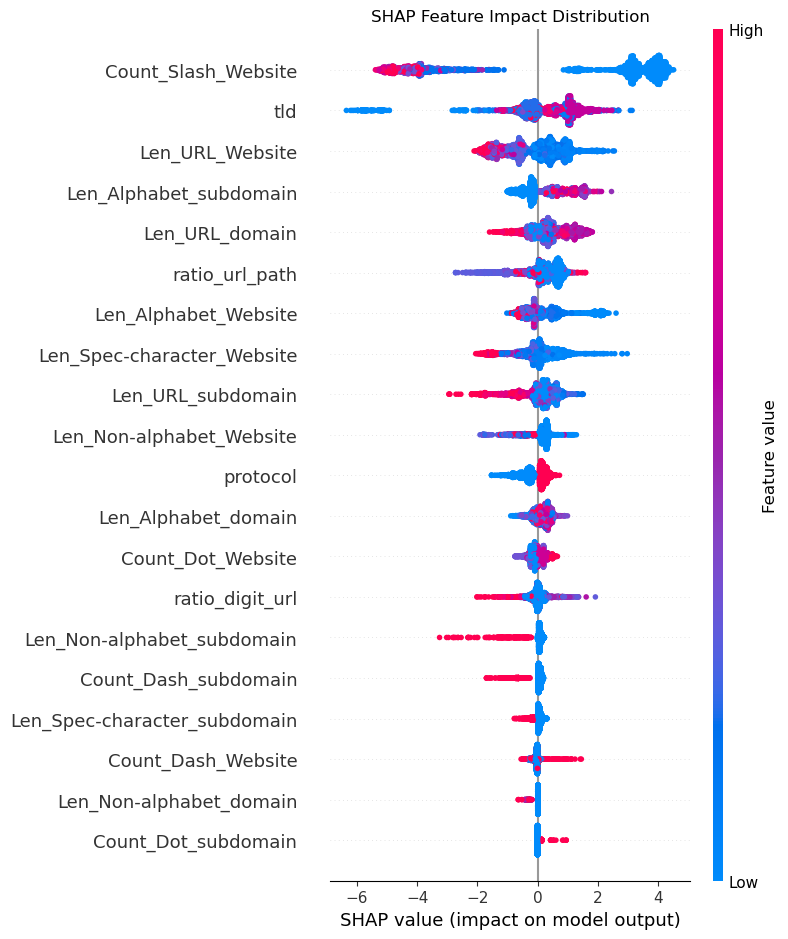

In [29]:
import shap

# Gunakan model XGBoost langsung
explainer = shap.TreeExplainer(modelXGB)

# Jika x_train adalah DataFrame, langsung dipakai
shap_values = explainer.shap_values(x_train)

# Ambil nama kolom (fitur)
if isinstance(x_train, pd.DataFrame):
    feature_names = x_train.columns
else:
    feature_names = [f"Feature {i}" for i in range(x_train.shape[1])]

# Plot SHAP summary plot
plt.figure(figsize=(12, 8))
plt.title("SHAP Feature Impact Distribution")
shap.summary_plot(shap_values, x_train, feature_names=feature_names)
plt.show()


In [30]:
file_name = "modelAI.pkl"

# Simpan model ke file
pickle.dump(best_classifierXG, open(file_name, "wb"))

# Muat model dari file
xgb_model_loaded = pickle.load(open(file_name, "rb"))

# Prediksi menggunakan model yang dimuat
y_pred_loaded = xgb_model_loaded.predict(x_test)

# Tampilkan hasil evaluasi
print('Accuracy:', accuracy_score(y_test, y_pred_loaded))
print('Classification Report:')
print(classification_report(y_test, y_pred_loaded))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_loaded))

Accuracy: 0.9767932489451476
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       329
           1       0.98      0.98      0.98       619

    accuracy                           0.98       948
   macro avg       0.97      0.97      0.97       948
weighted avg       0.98      0.98      0.98       948

Confusion Matrix:
[[318  11]
 [ 11 608]]
